In [7]:
!git clone https://github.com/dramirezbe/DataBase-RF-FM-88MHz-108MHz-Bogota-Funza.git

fatal: destination path 'DataBase-RF-FM-88MHz-108MHz-Bogota-Funza' already exists and is not an empty directory.


Loading CSVs: 100%|██████████| 6/6 [00:02<00:00,  2.17it/s]


Loaded 6 nodes from 6 files.
Node1-Bogota: center=98.000 MHz | noise_floor(Q0.20)=-23.09 dB | center_spike=3.93 dB | significant=False
Node10-Bogota: center=98.000 MHz | noise_floor(Q0.20)=-22.50 dB | center_spike=6.43 dB | significant=True
Node2-Bogota: center=98.000 MHz | noise_floor(Q0.20)=-22.84 dB | center_spike=4.82 dB | significant=False
Node4-Bogota: center=98.000 MHz | noise_floor(Q0.20)=-23.37 dB | center_spike=3.14 dB | significant=False
Node5-Bogota: center=98.000 MHz | noise_floor(Q0.20)=-21.75 dB | center_spike=0.86 dB | significant=False
Node7-Bogota: center=98.000 MHz | noise_floor(Q0.20)=-22.12 dB | center_spike=1.78 dB | significant=False


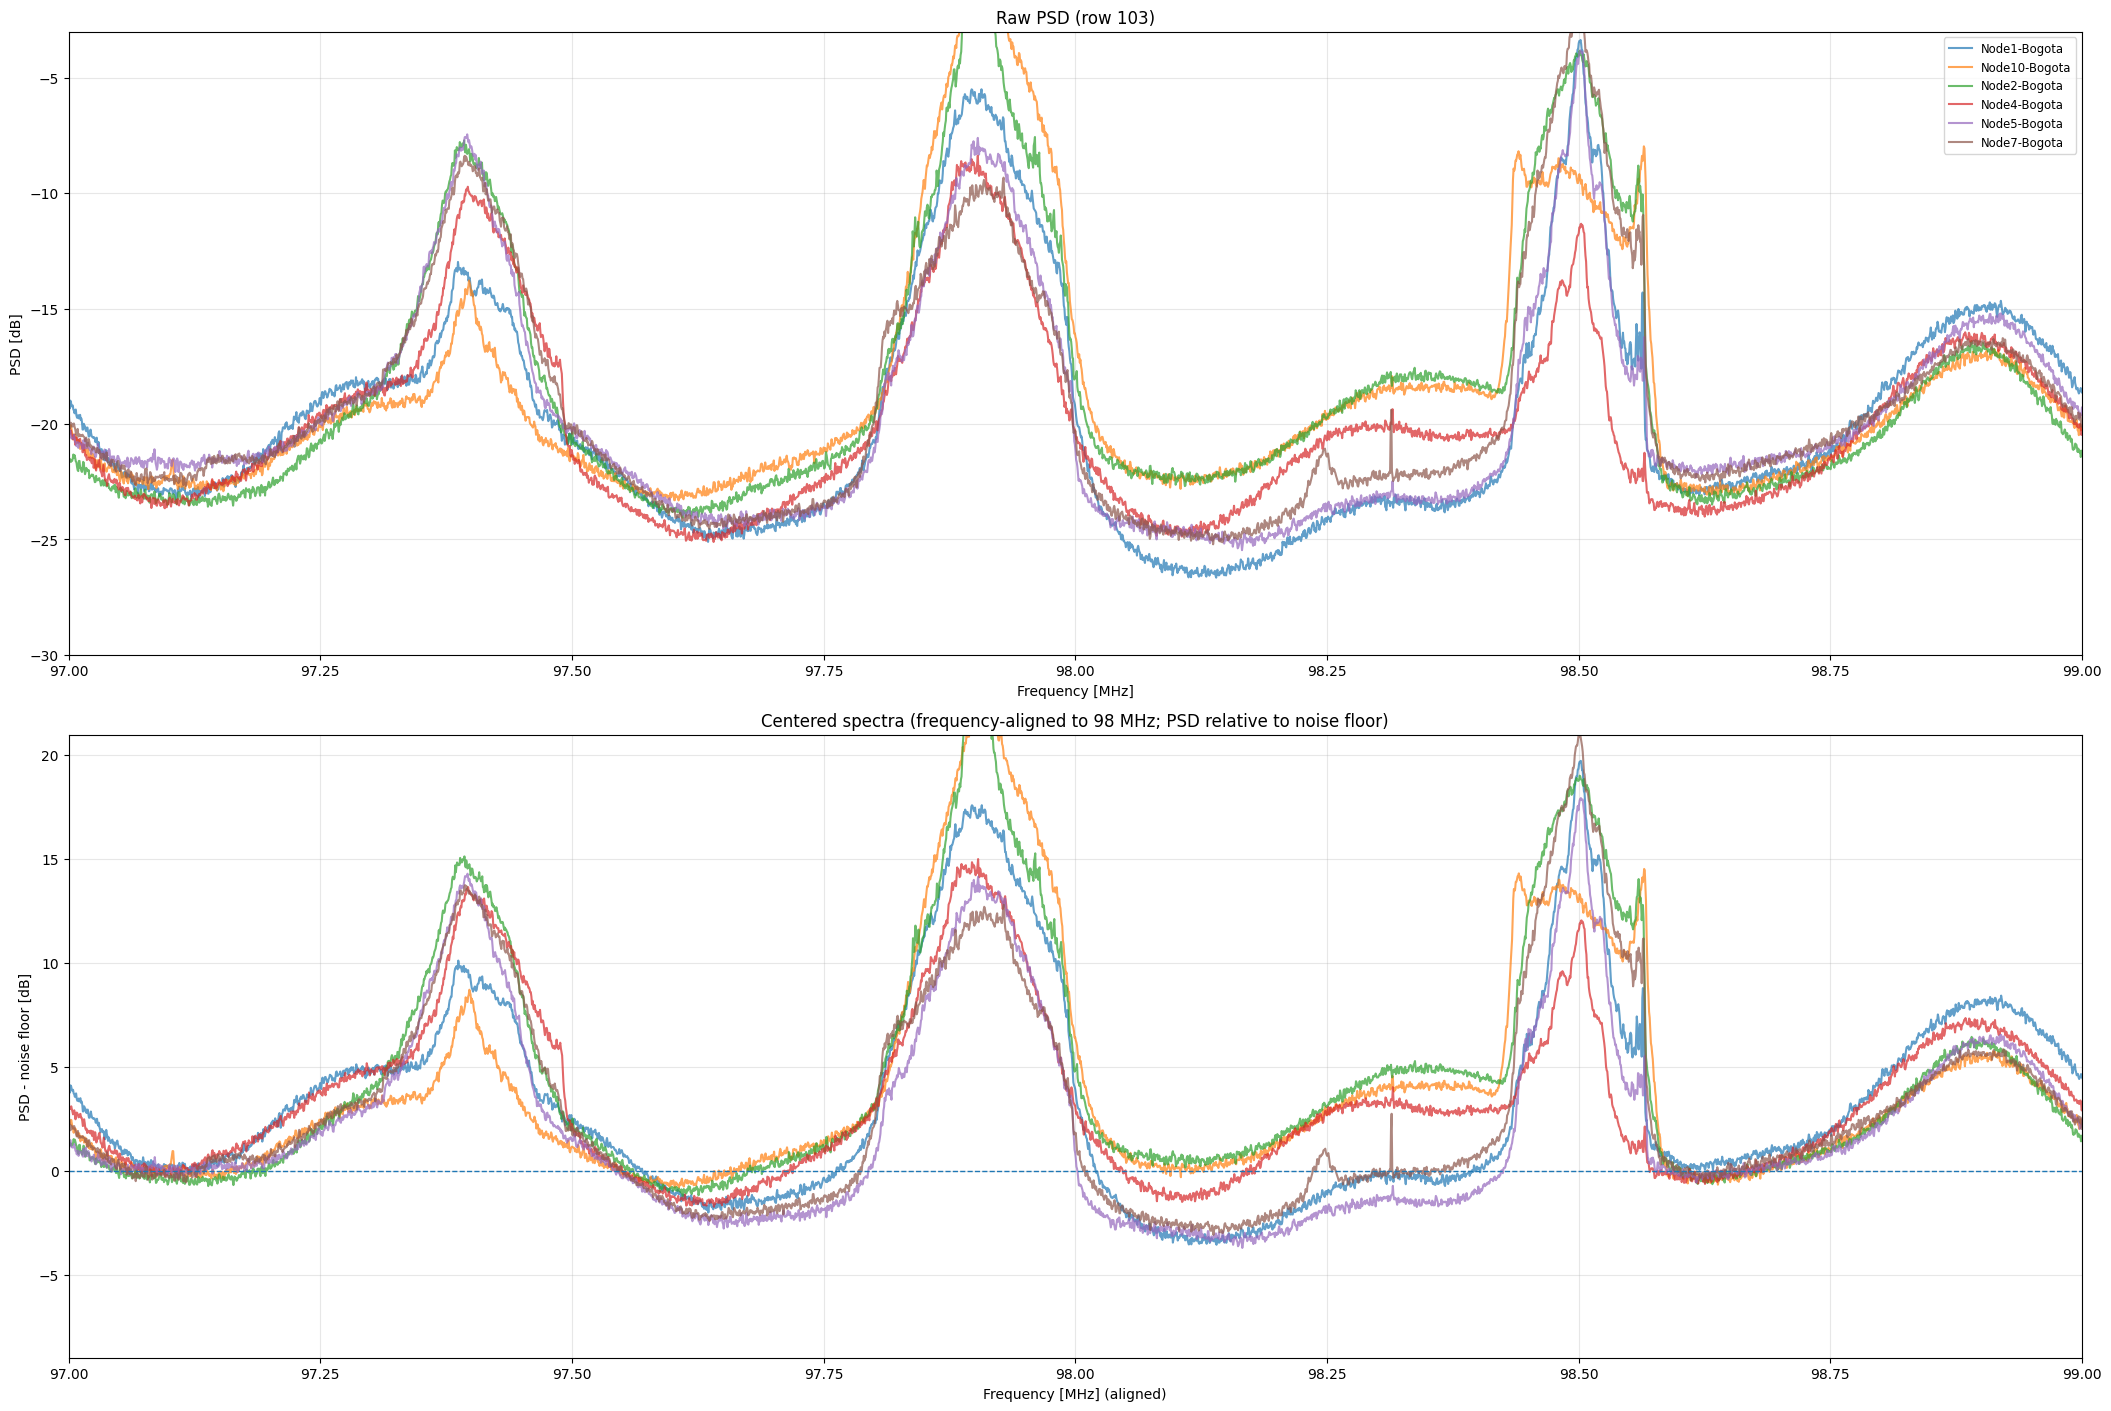


MI matrix (bits):
               Node1-Bogota  Node10-Bogota  Node2-Bogota  Node4-Bogota  Node5-Bogota  Node7-Bogota
Node1-Bogota         5.1018         1.4844        1.4772        1.7058        1.5703        1.7590
Node10-Bogota        1.4844         4.8962        1.8578        1.8755        1.5404        1.6049
Node2-Bogota         1.4772         1.8578        4.9538        1.6217        1.5760        1.7581
Node4-Bogota         1.7058         1.8755        1.6217        5.1393        1.6588        1.6732
Node5-Bogota         1.5703         1.5404        1.5760        1.6588        4.7190        1.6035
Node7-Bogota         1.7590         1.6049        1.7581        1.6732        1.6035        4.9541


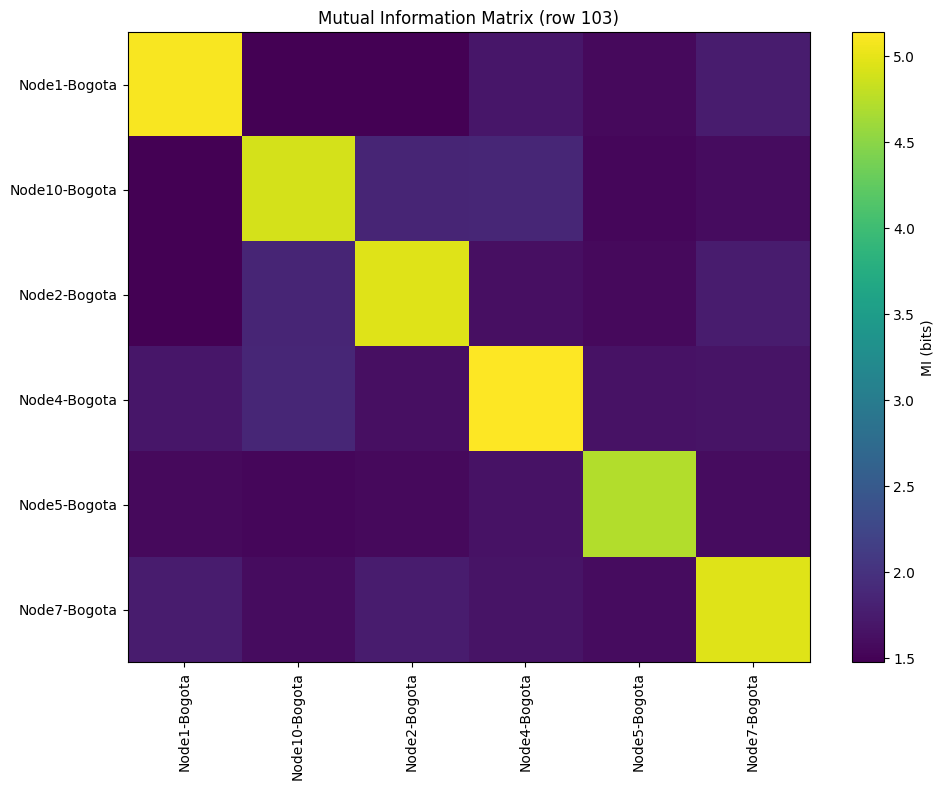


Cumulative estimate (descending):
Node4-Bogota     8.534988
Node7-Bogota     8.398706
Node10-Bogota    8.363079
Node2-Bogota     8.290763
Node1-Bogota     7.996625
Node5-Bogota     7.949019


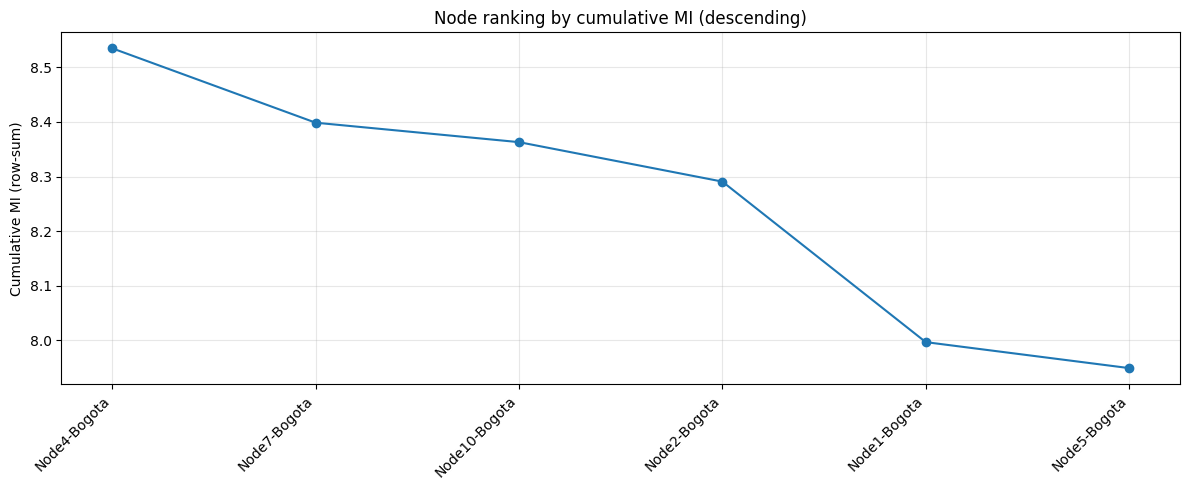

In [8]:
import glob, os, ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

def load_node_csvs(
    root_pattern: str,
    *,
    exclude_basenames=None,
    read_csv_kwargs=None,
    show_progress: bool = True,
):
    exclude = set(exclude_basenames or [])
    read_csv_kwargs = dict(read_csv_kwargs or {})

    archivos_all = sorted(glob.glob(root_pattern))
    archivos = [p for p in archivos_all
                if os.path.splitext(os.path.basename(p))[0] not in exclude]

    iterator = tqdm(archivos, desc="Loading CSVs") if show_progress else archivos

    datos_nodos = {}
    errors = []
    for archivo in iterator:
        nombre_nodo = os.path.splitext(os.path.basename(archivo))[0]
        try:
            datos_nodos[nombre_nodo] = pd.read_csv(archivo, **read_csv_kwargs)
        except Exception as e:
            errors.append((archivo, str(e)))

    return datos_nodos, archivos, errors

def parse_pxx_cell(pxx_raw):
    """Parse a CSV cell containing a list-like PSD into a 1D float array."""
    if isinstance(pxx_raw, (list, np.ndarray)):
        pxx = np.asarray(pxx_raw, dtype=float).ravel()
        return pxx

    s = str(pxx_raw).strip()
    # fast path: "[1,2,3]" -> fromstring
    if s.startswith("[") and s.endswith("]"):
        pxx = np.fromstring(s[1:-1], sep=",", dtype=float)
    else:
        pxx = np.asarray(ast.literal_eval(s), dtype=float)

    return np.asarray(pxx, dtype=float).ravel()

def to_db(pxx, *, scale="dB", eps=1e-12):
    pxx = np.asarray(pxx, dtype=float)
    if scale == "linear":
        pxx_db = 10.0 * np.log10(np.maximum(pxx, eps))
    elif scale == "dB":
        pxx_db = pxx.copy()
    else:
        raise ValueError("scale must be 'dB' or 'linear'")
    return np.where(np.isfinite(pxx_db), pxx_db, np.nan)

def detect_center_spike(
    frequencies,
    pxx,
    *,
    scale="dB",
    target_freq=None,
    guard_bins=2,
    baseline_mode="median",  # "median" or "quantile"
    baseline_q=0.2,
    threshold_db=6.0,
    eps=1e-12,
):
    pxx = np.asarray(pxx, dtype=float).ravel()
    freqs = np.asarray(frequencies, dtype=float).ravel()
    if pxx.size == 0 or freqs.size != pxx.size:
        raise ValueError("frequencies and pxx must be same non-zero length")

    # spike bin index
    if target_freq is None:
        k0 = pxx.size // 2
    else:
        k0 = int(np.argmin(np.abs(freqs - float(target_freq))))

    pxx_db = to_db(pxx, scale=scale, eps=eps)

    idx = np.arange(pxx_db.size)
    mask = np.abs(idx - k0) > int(guard_bins)
    if not np.any(mask):
        raise ValueError("guard_bins too large for PSD length")

    baseline_vals = pxx_db[mask]
    if baseline_mode == "median":
        baseline_db = np.nanmedian(baseline_vals)
    elif baseline_mode == "quantile":
        baseline_db = np.nanquantile(baseline_vals, baseline_q)
    else:
        raise ValueError("baseline_mode must be 'median' or 'quantile'")

    center_db = pxx_db[k0]
    spike_db = center_db - baseline_db
    spike_ratio = 10.0 ** (spike_db / 10.0)
    is_significant = bool(spike_db >= threshold_db)

    return dict(
        index=k0,
        freq=freqs[k0],
        baseline_db=baseline_db,
        center_db=center_db,
        spike_db=spike_db,
        spike_ratio=spike_ratio,
        is_significant=is_significant,
        pxx_db=pxx_db,
        mask_baseline=mask,
    )

def estimate_noise_floor_db(pxx_db, mask=None, q=0.2):
    """Noise floor estimate via low quantile (robust against carriers)."""
    vals = pxx_db[mask] if mask is not None else pxx_db
    return float(np.nanquantile(vals, q))

def _entropy_1d_from_hist(p, *, base=2.0):
    """Entropy from a probability vector p."""
    p = p[p > 0]
    if p.size == 0:
        return np.nan
    H = -np.sum(p * np.log(p))
    return H / np.log(base)

def mutual_information_hist(
    x: np.ndarray,
    y: np.ndarray,
    *,
    bins=64,
    x_edges=None,
    y_edges=None,
    value_range=None,      # tuple (lo, hi) used when x_edges/y_edges are None
    base: float = 2.0,
    normalized: bool = False,  # NMI = MI / sqrt(Hx*Hy)
    eps: float = 1e-15,
):
    """
    Histogram-based mutual information between 1D arrays x and y.
    Returns MI in 'base' units (bits if base=2).
    """
    x = np.asarray(x, dtype=float).ravel()
    y = np.asarray(y, dtype=float).ravel()

    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]; y = y[m]
    if x.size == 0:
        return np.nan

    if x_edges is None or y_edges is None:
        if value_range is None:
            lo = float(np.nanmin(np.concatenate([x, y])))
            hi = float(np.nanmax(np.concatenate([x, y])))
        else:
            lo, hi = map(float, value_range)
        if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
            return np.nan
        x_edges = np.linspace(lo, hi, int(bins) + 1)
        y_edges = np.linspace(lo, hi, int(bins) + 1)

    # Joint histogram
    Hxy, _, _ = np.histogram2d(x, y, bins=[x_edges, y_edges])
    Pxy = Hxy / (np.sum(Hxy) + eps)

    Px = np.sum(Pxy, axis=1)
    Py = np.sum(Pxy, axis=0)

    # MI = sum Pxy log(Pxy / (Px Py))
    denom = (Px[:, None] * Py[None, :]) + eps
    ratio = (Pxy + eps) / denom
    MI = np.sum(Pxy * np.log(ratio))
    MI = MI / np.log(base)

    if not normalized:
        return MI

    Hx = _entropy_1d_from_hist(Px, base=base)
    Hy = _entropy_1d_from_hist(Py, base=base)
    if not np.isfinite(Hx) or not np.isfinite(Hy) or Hx <= 0 or Hy <= 0:
        return np.nan
    return MI / np.sqrt(Hx * Hy)

def compute_mi_matrix(
    vectors_by_node: dict,
    *,
    bins: int = 64,
    qrange=(1.0, 99.0),    # robust global range for binning (percentiles)
    base: float = 2.0,
    normalized: bool = False,
):
    """
    Compute MI matrix across nodes. Uses a GLOBAL bin range for consistency.
    vectors_by_node: {node_name: 1D-array}
    Returns: (mi_df, used_range)
    """
    names = sorted(vectors_by_node.keys())
    if len(names) == 0:
        return pd.DataFrame(), None

    # Robust global bin range across all nodes (so MI values are comparable)
    all_vals = []
    for n in names:
        v = np.asarray(vectors_by_node[n], dtype=float).ravel()
        v = v[np.isfinite(v)]
        if v.size:
            all_vals.append(v)
    if not all_vals:
        return pd.DataFrame(index=names, columns=names, dtype=float), None

    all_vals = np.concatenate(all_vals)
    lo = float(np.nanpercentile(all_vals, qrange[0]))
    hi = float(np.nanpercentile(all_vals, qrange[1]))
    if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
        lo = float(np.nanmin(all_vals))
        hi = float(np.nanmax(all_vals))

    edges = np.linspace(lo, hi, int(bins) + 1)

    M = np.full((len(names), len(names)), np.nan, dtype=float)
    for i, ni in enumerate(names):
        xi = vectors_by_node[ni]
        for j, nj in enumerate(names):
            if j < i:
                M[i, j] = M[j, i]
                continue
            yj = vectors_by_node[nj]
            mij = mutual_information_hist(
                xi, yj,
                x_edges=edges, y_edges=edges,
                base=base,
                normalized=normalized,
            )
            M[i, j] = mij
            M[j, i] = mij

    mi_df = pd.DataFrame(M, index=names, columns=names)
    return mi_df, (lo, hi)

def build_vectors_for_row(
    datos_nodos: dict,
    row_idx: int,
    *,
    pxx_col: str = "pxx",
    pxx_scale: str = "dB",
    center_freq_mhz: float = 98.0,
    guard_bins: int = 2,
    noise_q: float = 0.2,
    roi=(97.0, 99.0),
    grid_n: int = 512,
):
    """
    For a given row, return dict {node: vector_on_common_grid}, where each vector is:
      - PSD in dB
      - noise-floor centered (pxx_db - noise_floor)
      - frequency-aligned so detected center bin maps to center_freq_mhz
      - interpolated onto a shared frequency grid in roi
    """
    fmin, fmax = map(float, roi)
    grid = np.linspace(fmin, fmax, int(grid_n))

    vectors = {}
    nodes_used = []

    for nombre_nodo, df in datos_nodos.items():
        if pxx_col not in df.columns:
            continue
        if not (0 <= row_idx < len(df)):
            continue

        # parse PSD vector
        try:
            pxx = parse_pxx_cell(df[pxx_col].iloc[row_idx])
        except Exception:
            continue
        if pxx.size == 0:
            continue

        # placeholder freq axis (replace with true bins if available)
        # ✅  Read the actual axis from the CSV if it is stored there,
        #     OR derive it from sample_rate and fft_size columns:
        if "freq_mhz" in df.columns:
            freqs_mhz = df["freq_mhz"].iloc[row_idx]  # stored per-row
        elif {"sample_rate_hz", "fft_size"}.issubset(df.columns):
            fs   = df["sample_rate_hz"].iloc[row_idx]
            N    = int(df["fft_size"].iloc[row_idx])
            fc   = df["center_freq_hz"].iloc[row_idx] / 1e6
            freqs_mhz = (np.fft.rfftfreq(N, 1/fs) + (fc - fs/2e6))

        # detect center bin + baseline
        res = detect_center_spike(
            freqs_mhz, pxx,
            scale=pxx_scale,
            target_freq=center_freq_mhz,
            guard_bins=guard_bins,
            baseline_mode="quantile",
            baseline_q=noise_q,
            threshold_db=6.0,
        )

        # use the same baseline as noise floor
        noise_floor_db = res["baseline_db"]

        # frequency align + level center
        freqs_aligned_mhz = freqs_mhz + (center_freq_mhz - res["freq"])
        pxx_centered = res["pxx_db"] - noise_floor_db

        # interpolate onto common grid (NaN outside support)
        y = np.interp(grid, freqs_aligned_mhz, pxx_centered, left=np.nan, right=np.nan)

        # if too few finite samples, skip
        if np.isfinite(y).sum() < max(16, grid_n // 10):
            continue

        vectors[nombre_nodo] = y
        nodes_used.append(nombre_nodo)

    return grid, vectors, nodes_used

def cumulative_mi_scores_for_row(
    vectors_by_node: dict,
    *,
    mi_bins: int = 64,
    qrange=(1, 99),
    base: float = 2.0,
    normalized: bool = False,
):
    """
    Compute MI matrix and cumulative MI score per node (row-sum, diagonal excluded).
    Returns: (mi_df, scores_series)
    """
    mi_df, _ = compute_mi_matrix(
        vectors_by_node,
        bins=mi_bins,
        qrange=qrange,
        base=base,
        normalized=normalized,
    )

    # Exclude diagonal using a writable NumPy copy (some DataFrame backends are read-only).
    mi_no_diag = mi_df.copy()
    mi_no_diag_values = mi_no_diag.to_numpy(copy=True)
    np.fill_diagonal(mi_no_diag_values, 0.0)
    mi_no_diag = pd.DataFrame(mi_no_diag_values, index=mi_no_diag.index, columns=mi_no_diag.columns)

    scores = mi_no_diag.sum(axis=1, skipna=True).astype(float)
    return mi_df, scores


def compute_rankings_over_rows(
    datos_nodos,
    row_range=range(0, 104),
    *,
    pxx_scale: str = "dB",
    center_freq_mhz: float = 98.0,
    guard_bins: int = 2,
    noise_q: float = 0.2,
    roi=(97.0, 99.0),
    grid_n: int = 512,
    mi_bins: int = 64,
    normalized: bool = False,
    verbose: bool = True,
):
    """
    For each row in row_range, compute cumulative MI score per node and rank them.
    Returns:
      scores_df: index=row_idx, columns=node, values=cumulative score
      ranks_df : same shape, rank 1 = best
    """
    all_nodes = sorted(datos_nodos.keys())
    scores_rows = {}

    for r in tqdm(list(row_range), desc="Rows (MI ranking)"):
        _, vectors = build_vectors_for_row(
            datos_nodos, r,
            pxx_scale=pxx_scale,
            center_freq_mhz=center_freq_mhz,
            guard_bins=guard_bins,
            noise_q=noise_q,
            roi=roi,
            grid_n=grid_n,
        )

        if len(vectors) < 2:
            # not enough nodes for MI; fill NaNs
            scores_rows[r] = pd.Series(index=all_nodes, dtype=float)
            if verbose:
                print(f"Row {r}: insufficient vectors ({len(vectors)})")
            continue

        mi_df, scores = cumulative_mi_scores_for_row(
            vectors,
            mi_bins=mi_bins,
            qrange=(1, 99),
            base=2.0,
            normalized=normalized,
        )

        # align to full node list
        s = pd.Series(index=all_nodes, dtype=float)
        s.loc[scores.index] = scores.values
        scores_rows[r] = s

        if verbose:
            top = scores.sort_values(ascending=False).head(3)
            print(f"Row {r}: top nodes -> {top.to_dict()}")

    scores_df = pd.DataFrame.from_dict(scores_rows, orient="index").sort_index()
    # rank: 1 = highest score; NaNs stay NaN
    ranks_df = scores_df.rank(axis=1, ascending=False, method="min", na_option="keep")
    return scores_df, ranks_df


def plot_rank_trajectories(ranks_df: pd.DataFrame, *, top_k: int = 8, title="Node rank vs ROW_PLOT"):
    """
    Plot rank (1=best) trajectories for top_k nodes chosen by best median rank.
    """
    # choose nodes with best (lowest) median rank across rows
    med = ranks_df.median(axis=0, skipna=True).sort_values()
    nodes = med.index[:top_k]

    plt.figure(figsize=(14, 6))
    x = ranks_df.index.values
    for n in nodes:
        plt.plot(x, ranks_df[n].values, marker="o", linewidth=1, label=n)

    plt.gca().invert_yaxis()
    plt.xlabel("ROW_PLOT")
    plt.ylabel("Rank (1 = best)")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend(loc="best", fontsize="small")
    plt.tight_layout()
    plt.show()


def plot_score_trajectories(scores_df: pd.DataFrame, *, top_k: int = 8, title="Cumulative MI score vs ROW_PLOT"):
    """
    Plot score trajectories for top_k nodes chosen by highest median score.
    """
    med = scores_df.median(axis=0, skipna=True).sort_values(ascending=False)
    nodes = med.index[:top_k]

    plt.figure(figsize=(14, 6))
    x = scores_df.index.values
    for n in nodes:
        plt.plot(x, scores_df[n].values, marker="o", linewidth=1, label=n)

    plt.xlabel("ROW_PLOT")
    plt.ylabel("Cumulative MI (row-sum, diag excluded)")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend(loc="best", fontsize="small")
    plt.tight_layout()
    plt.show()

# -----------------------
# Config
# -----------------------
ROOT_PATTERN = "DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node*.csv"
EXCLUDE_BASENAME = {"Node8-Bogota", "Node3-Bogota", "Node9-Funza", "Node6-Bogota"}
ROW_PLOT = 103

#each CSV row is already an averaged Welch PSD
# PSD format
PXX_SCALE = "dB"       # "dB" if stored in dB, "linear" if stored as linear power
CENTER_FREQ_MHZ = 98.0 # analysis center (band center)

# (1) Compute guard dynamically from actual bin resolution:
# Compute GUARD_BINS from FM band constants — no runtime dependency
FM_BAND_MHZ    = 20.0          # 108 - 88 MHz
DEFAULT_N_BINS = 1024          # typical FFT size; adjust if different
bin_res_mhz    = FM_BAND_MHZ / (DEFAULT_N_BINS - 1)
fm_half_bw_mhz = 0.200         # ±200 kHz FM occupied BW
GUARD_BINS     = int(np.ceil(fm_half_bw_mhz / bin_res_mhz)) + 1  # ✅

NOISE_Q = 0.2          # 20th percentile

datos_nodos, archivos, errors = load_node_csvs(
    ROOT_PATTERN,
    exclude_basenames=EXCLUDE_BASENAME,
    show_progress=True,
)

print(f"Loaded {len(datos_nodos)} nodes from {len(archivos)} files.")
if errors:
    print("Errors:")
    for f, msg in errors:
        print(f"  {f}: {msg}")

# -----------------------
# Plot (top: raw PSD, bottom: centered)
# -----------------------
fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(21, 14), sharex=False, constrained_layout=True)

pxx_centered_by_node = {}   # add before the loop
for nombre_nodo, df in datos_nodos.items():
    if "pxx" not in df.columns:
        print(f"⚠️ {nombre_nodo}: missing 'pxx' column")
        continue
    if not (0 <= ROW_PLOT < len(df)):
        print(f"⚠️ {nombre_nodo}: ROW_PLOT out of range")
        continue

    # parse PSD vector
    try:
        pxx = parse_pxx_cell(df["pxx"].iloc[ROW_PLOT])
    except Exception as e:
        print(f"⚠️ {nombre_nodo}: failed to parse pxx: {e}")
        continue

    if pxx.size == 0:
        print(f"⚠️ {nombre_nodo}: empty pxx")
        continue

    # Placeholder RF axis (replace with true bin centers if available in CSV)
    freqs_mhz = np.linspace(88.0, 108.0, pxx.size, endpoint=True)

    # detect spike + get baseline mask
    res = detect_center_spike(
        freqs_mhz, pxx,
        scale=PXX_SCALE,
        target_freq=CENTER_FREQ_MHZ,
        guard_bins=GUARD_BINS,
        baseline_mode="quantile",  # better for noise floor in presence of carriers
        baseline_q=NOISE_Q,
        threshold_db=6.0,
    )
    # Collect noise floors during the loop
    noise_floors = {}

    # Noise floor estimate (explicit)
    noise_floor_db = estimate_noise_floor_db(res["pxx_db"], mask=res["mask_baseline"], q=NOISE_Q)

    # --- TOP: raw PSD (use dB if already in dB; else plot converted dB)
    ax_top.plot(freqs_mhz, res["pxx_db"], label=nombre_nodo, alpha=0.7)

    # --- BOTTOM: centered (keep RF MHz axis 97..99)
    # 1) frequency-align so each node's detected center bin maps to CENTER_FREQ_MHZ (e.g., 98.0)
    freqs_aligned_mhz = freqs_mhz + (CENTER_FREQ_MHZ - res["freq"])

    # 2) level-center: subtract node noise floor so all floors align
    pxx_centered = res["pxx_db"] - noise_floor_db
    pxx_centered_by_node[nombre_nodo] = pxx_centered

    ax_bot.plot(freqs_aligned_mhz, pxx_centered, label=nombre_nodo, alpha=0.7)
    print(
        f"{nombre_nodo}: "
        f"center={res['freq']:.3f} MHz | "
        f"noise_floor(Q{NOISE_Q:.2f})={noise_floor_db:.2f} dB | "
        f"center_spike={res['spike_db']:.2f} dB | "
        f"significant={res['is_significant']}"
    )

mi_df, used_range = compute_mi_matrix(
    pxx_centered_by_node,
    bins=64,
    qrange=(1, 99),
    base=2.0,
    normalized=False,   # set True if you want NMI
)

# cosmetics
ax_top.set_title(f"Raw PSD (row {ROW_PLOT})")
ax_top.set_xlabel("Frequency [MHz]")
ax_top.set_ylabel("PSD [dB]")
ax_top.grid(True, alpha=0.3)
ax_top.set_xlim(97, 99)
ax_top.set_ylim(-30 , -3 )
ax_top.legend(loc="best", fontsize="small")

ax_bot.set_title("Centered spectra (frequency-aligned to 98 MHz; PSD relative to noise floor)")
ax_bot.set_xlabel("Frequency [MHz] (aligned)")
ax_bot.set_ylabel("PSD - noise floor [dB]")
ax_bot.axhline(0.0, linestyle="--", linewidth=1.0)  # noise floor reference
ax_bot.grid(True, alpha=0.3)
ax_bot.set_ylim(-9 , 21)
ax_bot.set_xlim(97, 99)
plt.show()

print("\nMI matrix (bits):")
print(mi_df.round(4).to_string())

# Optional: heatmap with matplotlib
plt.figure(figsize=(10, 8))
plt.imshow(mi_df.values, aspect="auto")
_normalized = False   # match whatever you passed to compute_mi_matrix
label = "NMI (0–1)" if _normalized else "MI (bits)"
plt.colorbar(label=label)
plt.xticks(range(len(mi_df.columns)), mi_df.columns, rotation=90)
plt.yticks(range(len(mi_df.index)), mi_df.index)
plt.title(f"Mutual Information Matrix (row {ROW_PLOT})")
plt.tight_layout()
plt.show()

# --- Option B (usually better for comparing nodes): exclude diagonal self-MI ---
mi_no_diag = mi_df.copy()
mi_no_diag_values = mi_no_diag.to_numpy(copy=True)
np.fill_diagonal(mi_no_diag_values, 0.0)
mi_no_diag = pd.DataFrame(mi_no_diag_values, index=mi_no_diag.index, columns=mi_no_diag.columns)
row_sum_no_diag = mi_no_diag.sum(axis=1)

# Choose which one you want to use for ranking/plot:
scores = row_sum_no_diag   # <- recommended
# scores = row_sum_all     # <- literal interpretation

# Rank in decreasing order
scores_sorted = scores.sort_values(ascending=False)

print("\nCumulative estimate (descending):")
print(scores_sorted.to_string())

# Plot
plt.figure(figsize=(12, 5))
plt.plot(scores_sorted.values, marker="o")
plt.xticks(range(len(scores_sorted.index)), scores_sorted.index, rotation=45, ha="right")
plt.ylabel("Cumulative MI (row-sum)")
plt.title("Node ranking by cumulative MI (descending)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

observation \(1\): An FM station at 98 MHz occupies ±75 kHz \(audio deviation\) plus a 19 kHz pilot, 38 kHz stereo subcarrier, and optional RDS at 57 kHz — total occupied bandwidth ≈ ±200 kHz\. With a 20 MHz span and a typical FFT of 1024 bins the bin resolution is ~19\.5 kHz/bin\. To fully exclude the FM main channel, the guard needs to be at least ±11 bins\. At 2 bins the carrier sidebands leak into the baseline estimate, inflating the measured noise floor and suppressing the spike significance score\.

Issue: The alignment strategy freqs\_aligned\_mhz = freqs\_mhz \+ \(CENTER\_FREQ\_MHZ − res\["freq"\]\) performs a rigid linear frequency shift that implicitly assumes: \(a\) exactly one dominant peak exists near 98 MHz, and \(b\) that peak IS the intended carrier\. If a node is positioned near an adjacent FM station \(e\.g\., 97\.9 or 98\.1 MHz\) or if multipath creates a false peak, the entire spectrum will be shifted to align the wrong feature\. The subsequent MI matrix then measures similarity of wrongly aligned spectra\. 

Fix: Before shifting, verify that res\["is\_significant"\] is True and that res\["freq"\] falls within an acceptable tolerance window \(e\.g\., ±0\.1 MHz of the target\)\. Nodes that fail this check should be excluded from that row rather than silently mis\-aligned\.

Issue: The 64\-bin histogram is applied uniformly regardless of the actual dB dynamic range of the data\. If the centred PSD spans only 5 dB \(low SNR node\), 64 bins gives a bin width of <0\.1 dB — finer than the measurement noise \(~1–3 dB per bin\) — causing most bins to be empty and inflating the MI estimate\. Conversely, a high\-SNR node spanning 30 dB gets 0\.47 dB/bin bins — perhaps too coarse to resolve spectral shape differences\. The two situations are mixed in the same global\-edge matrix, making the MI values across nodes not directly comparable\.

Fix: Select bin count via Scott's or Freedman–Diaconis rule per vector, or use a fixed physical resolution \(e\.g\., 0\.5 dB/bin\) so that the histogram discretisation is anchored to a meaningful signal unit rather than an arbitrary integer\.

Issue: Select bin count via Scott's or Freedman–Diaconis rule per vector, or use a fixed physical resolution \(e\.g\., 0\.5 dB/bin\) so that the histogram discretisation is anchored to a meaningful signal unit rather than an arbitrary integer\.

Fix: Use Normalised Mutual Information: NMI = MI / sqrt\(H\(X\)·H\(Y\)\)\. The function already supports this via normalized=True — it just needs to be enabled as the default for node ranking\. Absolute MI can remain available for diagnostic plots\.

Issue: Absolute MI \(in bits\) grows with the variance of the marginal distributions\. A node with a strong, sharp carrier will have a high\-entropy PSD vector and thus artificially high MI with every other node — not because it shares more channel information, but because its marginal entropy H\(X\) is larger\. The cumulative MI score then systematically favours high\-power or high\-SNR nodes over nodes with weaker but genuinely correlated signals\.

Fix: Use Normalised Mutual Information: NMI = MI / sqrt\(H\(X\)·H\(Y\)\)\. The function already supports this via normalized=True — it just needs to be enabled as the default for node ranking\. Absolute MI can remain available for diagnostic plots\.

Issue: The 2 MHz ROI is centred on the 98 MHz carrier\. After frequency alignment the carrier sits at 98 MHz, meaning the ROI only captures 1 MHz of lower sideband and 1 MHz of upper sideband\. FM stereo subcarrier content \(at ±38 kHz from carrier\) and pilot \(±19 kHz\) are well within the window, but any RDS \(±57 kHz\) and adjacent channel content may be near the edges, causing edge\-interpolation artefacts for nodes with slight residual mis\-alignment\.

Fix: Widen the ROI slightly \(e\.g\., 96\.5–99\.5 MHz\) to provide margin, and consider applying a Hanning taper to the interpolated vector edges to reduce MI bias from abrupt truncation\.

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=c4818a93-f2bf-4892-b7a2-47816cd4c47d' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>